In [5]:
from data_cleanup import functions
regions = functions.regions

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

In [73]:
#angepasst auf finale datei
seq_regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
cf_regions = ['CF_H1', 'CF_H2', 'CF_L1', 'CF_L2', 'CF_L3']
df = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset=seq_regions)
    .dropna(subset=cf_regions)
    .drop_duplicates(subset=seq_regions) 
)
antigen_labels = df["antigen_name"].tolist()

In [74]:
feature_spaces = {}

seq_regions = ["SEQ_H1", "SEQ_H2", "SEQ_L1", "SEQ_L2", "SEQ_L3"]
cf_regions = ["CF_H1", "CF_H2", "CF_L1", "CF_L2", "CF_L3"]

df = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset = seq_regions)
    .dropna(subset = cf_regions)
    .drop_duplicates(subset = seq_regions)
)

df_rows = df[["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species"]].values.tolist()

for seq_region in seq_regions:
    fs_rows = []
    for df_row in df_rows:
        pdb = df_row[0]
        hchain = df_row[1]
        lchain = df_row[2]
        model = df_row[3]
        antigen_name = df_row[4]
        antigen_species = df_row[5]

        if seq_region[4] == "H": #z.B. "H" in "SEQ_H1" oder "L" in "SEQ_L2"
            chain_id = hchain
        else:
            chain_id = lchain

        # Embedding-Koordinaten der PDB-Einträge
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{chain_id}_{seq_region[4]}_{seq_region}_chothia.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        # Erstellen und Anhängen der Zeile eines PDB-Eintrages für den Feature-Space
        fs_row = [pdb, hchain, lchain, model, antigen_name, antigen_species] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)

    # Umwandeln des Feature-Space von einer List in einen DataFrame
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species"] + [f"embedding_dimension {e}" for e in range(embedding_as_vec.shape[0])])
    feature_spaces[seq_region] = feature_space

In [65]:
print(feature_spaces["SEQ_H1"].head())

    pdb sequence     emb_0     emb_1     emb_2     emb_3     emb_4     emb_5  \
0  8y3h  GGTFNNY  0.001255  0.107538 -0.027441 -0.075856  0.053811  0.002024   
1  8y3i  GYTFTSY  0.011708  0.139698 -0.043502 -0.076092  0.007718 -0.011156   
2  8y3k  GGTFNNY  0.001255  0.107538 -0.027441 -0.075856  0.053811  0.002024   
3  8vym  GYTFTDY -0.004650  0.136233 -0.034293 -0.083882 -0.006154 -0.021099   
4  8ker  GFTFRNY  0.044457  0.080275 -0.037222 -0.043166  0.007712  0.012235   

      emb_6     emb_7  ...  emb_1143  emb_1144  emb_1145  emb_1146  emb_1147  \
0  0.004542  0.037420  ... -0.055086  0.032174  0.012084 -0.002544 -0.001416   
1  0.000268  0.012871  ... -0.078795  0.021932  0.022262  0.030526  0.035073   
2  0.004542  0.037420  ... -0.055086  0.032174  0.012084 -0.002544 -0.001416   
3  0.024532  0.024227  ... -0.064379  0.036868  0.045069  0.016540  0.002925   
4  0.054107  0.018037  ... -0.070524  0.061749  0.010365  0.035650  0.009114   

   emb_1148  emb_1149  emb_1150  emb_1

Clustering SEQ_H1: 4528 Objekte, Dimensionen=1152


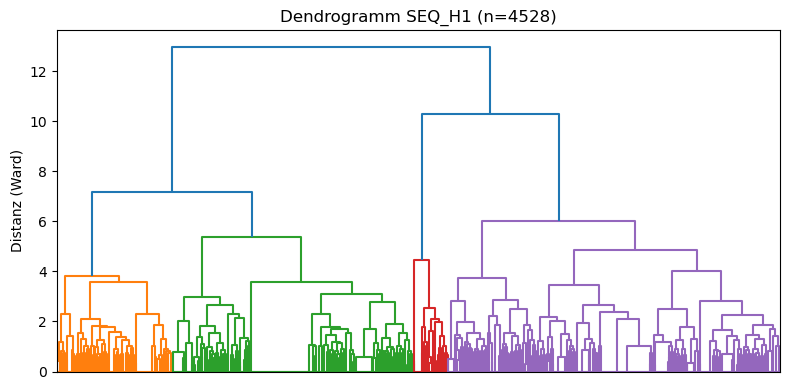

Clustering SEQ_H2: 4528 Objekte, Dimensionen=1152


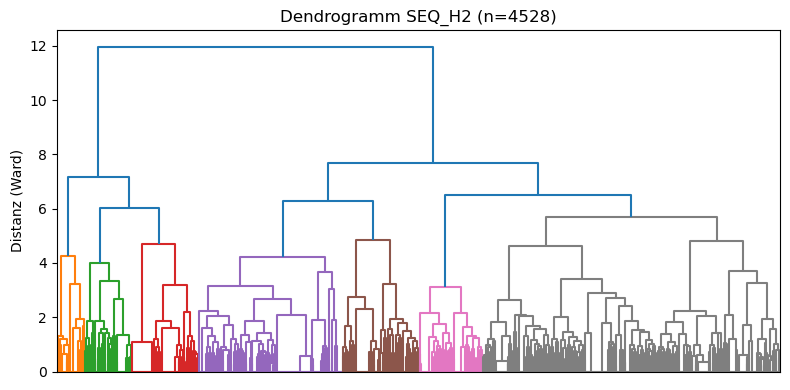

Clustering SEQ_L1: 4529 Objekte, Dimensionen=1152


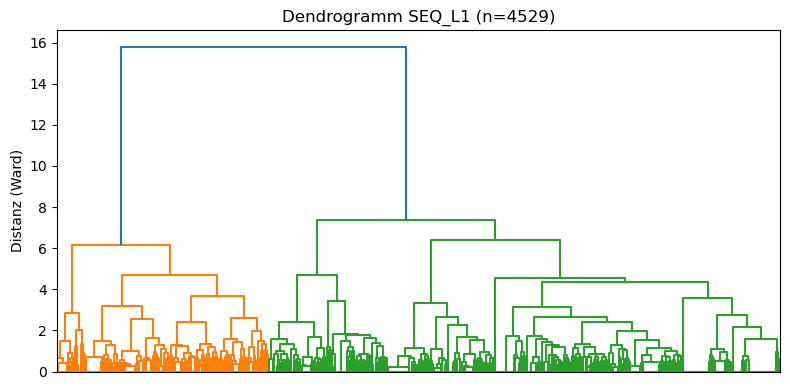

Clustering SEQ_L2: 4529 Objekte, Dimensionen=1152


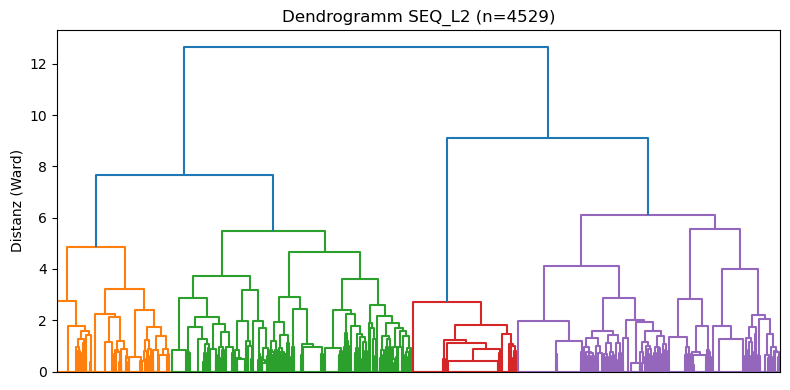

Clustering SEQ_L3: 4529 Objekte, Dimensionen=1152


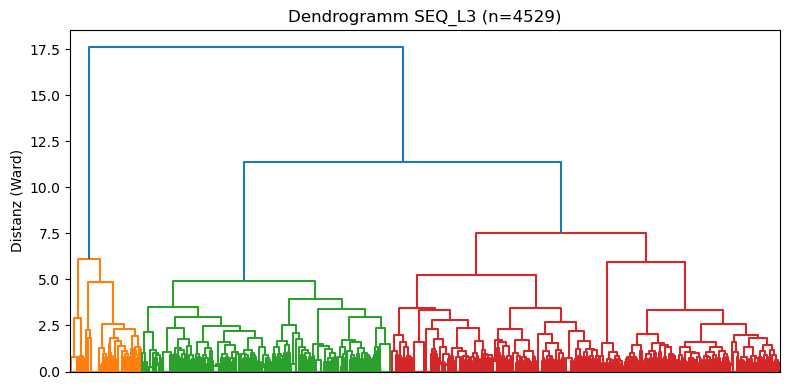

In [63]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# ---------- Konfiguration ----------
# Basisordner mit Embedding-Dateien (.npy)
emb_root = "data/embeddings"  # passe hier Dein Repo-Pfad an
# CDR-Regionen, die geclustert werden sollen
regions = ["SEQ_H1", "SEQ_H2", "SEQ_L1", "SEQ_L2", "SEQ_L3"]
# Dateiendung der Embeddings
emb_ext = ".npy"

# ---------- Hierarchisches Clustering pro Region ----------
# Optional: Verhältnis für Color-Threshold (0 bis 1, höher = mehr Cluster)
threshold_ratio = 0.5  # z.B. 0.5 = halbe Max-Distanz, anpassen für mehr/weniger Farben

for region in regions:
    # 1) Sammle alle Dateien, deren Name die Region enthält
    files = []
    for root, dirs, filenames in os.walk(emb_root):
        for fname in filenames:
            if fname.endswith(emb_ext) and region in fname:
                files.append(os.path.join(root, fname))
    files = sorted(files)
    if not files:
        print(f"Keine Embeddings für Region {region} gefunden. Überspringe {region}.")
        continue

    # 2) Embeddings laden und ggf. auf 1D-Vektor reduzieren
    embeddings, labels = [], []
    for path in files:
        emb = np.load(path)
        if emb.ndim > 1:
            emb = emb.mean(axis=0)
        embeddings.append(emb)
        labels.append(os.path.splitext(os.path.basename(path))[0])

    # 3) Zu Matrix stapeln und Clustering
    X = np.vstack(embeddings)
    print(f"Clustering {region}: {X.shape[0]} Objekte, Dimensionen={X.shape[1]}")
    Z = linkage(X, method="ward", metric="euclidean")
    # Bestimme Schwellenwert für Farb-Cluster anhand ratio
    max_dist = Z[-1, 2]
    threshold = threshold_ratio * max_dist

    # 4) Dendrogramm plotten (ohne x-Beschriftung)
    plt.figure(figsize=(8, 4))
    dendrogram(
        Z,
        labels=labels,
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=threshold  # auf ratio * max_dist gesetzt
    )
    plt.xticks([])
    plt.gca().set_xlabel("")
    plt.title(f"Dendrogramm {region} (n={len(labels)})")
    plt.ylabel("Distanz (Ward)")
    plt.tight_layout()
    plt.show()



In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# --------- Hierarchical Clustering aus bestehenden Feature-Spaces ---------
# Annahme: Du hast bereits ein Dict `feature_spaces` mit fünf DataFrames,
# je eines für SEQ_H1, SEQ_H2, SEQ_L1, SEQ_L2, SEQ_L3.
# Jeder DataFrame enthält Spalten:
#   ['pdb', 'Hchain', 'Lchain', 'sequence', 'emb_0', ..., 'emb_N']

threshold_ratio = 0.5  # 50% der maximalen Merge-Distanz als Cut

# Liste der Regionen, wie sie als Keys im Dict vorliegen
regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']

for region in regions:
    fs = feature_spaces.get(region)
    if fs is None or fs.empty:
        print(f"⚠️ Kein Feature-Space für {region} gefunden oder leer.")
        continue

    # 1) Embedding-Spalten sammeln
    emb_cols = [c for c in fs.columns if c.startswith('emb_')]
    if not emb_cols:
        print(f"⚠️ Keine Embedding-Spalten in feature_spaces['{region}'].")
        continue

    # 2) Feature-Matrix und Labels
    X = fs[emb_cols].values
    labels = fs['pdb'].astype(str) + '_' + fs['Hchain'].fillna('') + fs['Lchain'].fillna('')
    n = X.shape[0]
    print(f"\n→ {region}: {n} Sequenzen zum Clustern")
    if n < 2:
        print("   ▶ Zu wenige Einträge, überspringe.")
        continue

    # 3) Ward-Linkage
    Z = linkage(X, method='ward', metric='euclidean')
    max_dist = Z[-1, 2]
    cut = threshold_ratio * max_dist
    print(f"   MaxDist={max_dist:.3f}, Cut@{threshold_ratio*100:.0f}% = {cut:.3f}")

    # 4) Dendrogramm plotten
    plt.figure(figsize=(10, 4))
    dendrogram(
        Z,
        labels=labels.tolist(),
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=cut
    )
    plt.xticks([])
    plt.xlabel("")
    plt.ylabel("Distanz (Ward)")
    plt.title(f"Dendrogramm {region} (n={n}), Cut={int(threshold_ratio*100)}%")
    plt.tight_layout()
    plt.show()


⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_H1'].
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_H2'].
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_L1'].
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_L2'].
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_L3'].


In [76]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# --------- Hierarchisches Clustering direkt aus feature_spaces ---------
# Annahme:
#   - feature_spaces ist ein Dict mit Keys ['SEQ_H1','SEQ_H2','SEQ_L1','SEQ_L2','SEQ_L3']
#   - Jeder Value ist ein pandas DataFrame mit Spalten:
#       ['pdb','Hchain','Lchain','sequence','emb_0',...,'emb_N']
#   - Die Embedding-Spalten beginnen alle mit 'emb_'.

threshold_ratio = 0.5  # Cut bei 50% der maximalen Merge-Distanz

print("Verfügbare CDR-Regionen:", list(feature_spaces.keys()))

for region, fs in feature_spaces.items():
    print(f"\n=== Clustering für {region} ===")
    # 1) Embedding-Spalten identifizieren
    emb_cols = [c for c in fs.columns if c.startswith('emb_')]
    if not emb_cols:
        print(f"⚠️ Keine Embedding-Spalten in feature_spaces['{region}']")
        continue
    print(f"Gefundene Embedding-Spalten: {len(emb_cols)}")

    # 2) Feature-Matrix X und Labels
    X = fs[emb_cols].values
    labels = fs['pdb'].astype(str)
    if 'Hchain' in fs.columns and 'Lchain' in fs.columns:
        labels += '_' + fs['Hchain'].fillna('') + fs['Lchain'].fillna('')
    n = X.shape[0]
    print(f"Anzahl Sequenzen: {n}")
    if n < 2:
        print("Zu wenige Sequenzen, überspringe.")
        continue

    # 3) Ward-Linkage
    Z = linkage(X, method='ward', metric='euclidean')
    max_dist = Z[-1,2]
    cut = threshold_ratio * max_dist
    print(f"Max-Distanz={max_dist:.3f}, Cut-Schwelle={cut:.3f}")

    # 4) Dendrogramm
    plt.figure(figsize=(10,4))
    dendrogram(
        Z,
        labels=labels.tolist(),
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=cut
    )
    plt.xticks([])
    plt.ylabel("Distanz (Ward)")
    plt.title(f"Dendrogramm {region} (n={n}), cut={int(threshold_ratio*100)} %")
    plt.tight_layout()
    plt.show()


Verfügbare CDR-Regionen: ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']

=== Clustering für SEQ_H1 ===
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_H1']

=== Clustering für SEQ_H2 ===
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_H2']

=== Clustering für SEQ_L1 ===
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_L1']

=== Clustering für SEQ_L2 ===
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_L2']

=== Clustering für SEQ_L3 ===
⚠️ Keine Embedding-Spalten in feature_spaces['SEQ_L3']


In [ ]:
data_cleanup.functions.show_PCA(feature_spaces, 3)

In [ ]:
data_cleanup.functions.elbow(feature_spaces, 3)

In [ ]:
data_cleanup.functions.silhouette(feature_spaces, 3)

In [ ]:
# Auswahl der optimalen Clusterzahlen für silhouette_check und show_Kmeans
cluster_counts = {
    "CDR_H1": 4,
    "CDR_H2": 6,
    "CDR_L1": 5,
    "CDR_L2": 7,
    "CDR_L3": 2
}

In [ ]:
data_cleanup.functions.silhouette_check(feature_spaces, cluster_counts, ncols=3)

In [ ]:
data_cleanup.functions.show_Kmeans(feature_spaces, cluster_counts, 3)

In [ ]:
#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären


In [ ]:
# Brauchen wir erst mal nicht!
'''# Alternative: Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling
from scipy.spatial.distance import directed_hausdorff
from sklearn.manifold import MDS

subset_df = df.sample(300, random_state=42)


for region in regions:
    alle_embeddings = []
    labels = []
    for i, df_row in subset_df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        #antigen_species = df_row["antigen_species"]
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        alle_embeddings.append(embedding_as_arr)
        labels.append(antigen_name)
    n = len(alle_embeddings)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(dist_matrix)

    label_codes = pd.Categorical(labels).codes
    label_categories = pd.Categorical(labels).categories
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=label_codes, cmap='tab10', s=20)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")
    plt.title(f"Embeddings der {region} (Hausdorff)")
    plt.grid(True)
    plt.show()'''